In [1]:
import warnings
warnings.filterwarnings("ignore")

from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import pandas as pd
import numpy as np
import yfinance as yf

import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

from scipy.optimize import minimize_scalar
from scipy.stats import chi2, norm

# Data Processing

In [2]:
@dataclass
class Portfolio_Spec:
    tickers: List[str]
    weights: List[float]
    portfolio_value: float = 10_000_000.0
    start:str = "2007-01-01"
    end:Optional[str]= None

    def __post_init__(self):
        self.weights = np.asarray(self.weights,dtype = float)
        if len(self.weights) != len(self.tickers):
            raise ValueError("Tickers and Weights vector must have the same size")
        if not np.isclose(self.weights.sum(), 1.0):
            raise ValueError("Weights must add to 1")

In [3]:
def download_adjusted_close(tickers: List[str], start:str, end:Optional[str] = None):
    raw = yf.download(tickers=tickers,
                     start=start,
                     end = end,
                     auto_adjust=True,
                     group_by='column',
                     progress=False,
                     threads=True,
                     multi_level_index=True)
    if raw is None or raw.empty:
        raise ValueError("No data downloaded from yfinance")

    if isinstance(raw.columns,pd.MultiIndex):
        level0 = raw.columns.get_level_values(0)
        level1 = raw.columns.get_level_values(1)

        if "Close" in level0:
            close = raw["Close"].copy()
        elif "Close" in level1:
            close = raw.xs("Close",axis=1, level=1)
        else:
            raise ValueError("Could not find close field in column data")
    else:
        if "Close" in raw.columns:
            close = raw[["Close"]].copy()
            close.columns = tickers[:1]
    close = close.ffill().dropna(how = "any")
    close = close[tickers]
    return close

In [4]:
def compute_returns_frame(prices:pd.DataFrame):
    log_returns = np.log(prices/prices.shift(1)).dropna()
    simple_returns = np.exp(log_returns)-1.0
    mean_adjusted_returns = log_returns - log_returns.mean()
    return log_returns, simple_returns, mean_adjusted_returns

In [5]:
def build_portfolio_series(simple_returns:pd.DataFrame, weights:np.ndarray, portfolio_value:float):
    portfolio_returns = simple_returns@weights
    portfolio_pnl = portfolio_value*portfolio_returns
    portfolio_loss = -portfolio_pnl
    return pd.DataFrame({"portfolio_return":portfolio_returns,
                        "portfolio_pnl":portfolio_pnl,
                        "portfolio_loss":portfolio_loss},index=simple_returns.index)

# Core Risk Utility Functions

In [6]:
def var_from_pnl(pnl:pd.Series,confidence:float = 0.95):
    alpha = 1- confidence
    return float(-np.quantile(pnl.dropna(), alpha))

In [7]:
def es_from_pnl(pnl: pd.Series, confidence: float = 0.95):
    alpha = 1 - confidence
    q = np.quantile(pnl.dropna(), alpha)
    tail = pnl[pnl <= q]
    return float(tail.mean())

In [8]:
def exponential_weights(n:int, lam:float):
    powers = np.arange(n-1,-1,-1)
    w = (1-lam)*(lam**powers)
    return w/w.sum()

In [9]:
def weighted_quantiles(values:np.ndarray,quantiles:float,sample_weights:np.ndarray):
    sorter = np.argsort(values)
    x = values[sorter]
    w = sample_weights[sorter]
    cw = np.cumsum(w)
    cutoff = quantiles * w.sum()
    return float(np.interp(cutoff,cw,x))

In [10]:
def weighted_es_from_pnl(pnl: pd.Series, confidence: float, weights: np.ndarray):
    alpha = 1-confidence
    x = np.asarray(pnl)
    w = np.asarray(weights)

    sorter = np.argsort(x)
    x = x[sorter]
    w = w[sorter]
    cw = np.cumsum(w)
    cutoff = alpha * w.sum()
    q = np.interp(cutoff,cw,x)

    idx = np.searchsorted(cw,cutoff)
    prev_weight = cw[idx-1] if idx>0 else 0.0 
    partial_w = cutoff - prev_weight
    tail_x = list(x[:idx])
    tail_w = list(w[:idx])

    if idx < len(x):
        tail_x.append(x[idx])
        tail_w.append(partial_w)

    tail_x = np.asarray(tail_x)
    tail_w = np.asarray(tail_w)

    return float(-(tail_x * tail_w).sum() / cutoff)

# EWMA, MLE, covariance, Monte Carlo, delta-normal

In [11]:
def ewma_volatility(series:pd.Series,lam:float):
    r = series.dropna()
    mu = r.mean()
    sigma2 = np.zeros(len(r))
    sigma2[0] = r.var(ddof=1)

    for t in range(1,len(r)):
        sigma2[t] = lam*sigma2[t-1]+(1-lam)*(r.iloc[t-1]-mu)**2

    return pd.Series(np.sqrt(sigma2),index=r.index,name = "ewma_vol")

In [12]:
def ewma_neg_loglik(lam:float,returns:pd.DataFrame):
    if (lam > 1) or (lam < 0):
        return np.inf

    centered = returns - returns.mean()
    total = 0.0

    for col in centered.columns:
        r = centered[col].dropna().values
        sigma2 = np.zeros(len(r))
        sigma2[0] = np.var(r,ddof=1)

        for t in range(1,len(r)):
            sigma2[t] = lam * sigma2[t - 1] + (1 - lam) * (r[t - 1] ** 2)
        sigma2 = np.clip(sigma2,1e-12,None)
        total += 0.5 * np.sum(np.log(sigma2[1:]) + (r[1:] ** 2) / sigma2[1:])

    return float(total)

In [13]:
def estimate_lambda_mle(returns:pd.DataFrame):
    res = minimize_scalar(fun = lambda lam: ewma_neg_loglik(lam,returns),bounds=(0.80,0.999),method="bounded")
    return float(res.x), res

In [14]:
def volatility_scale_returns(log_returns:pd.DataFrame, lam:float):
    centered = log_returns - log_returns.mean()
    sigma_df = pd.DataFrame(index=log_returns.index,columns=log_returns.columns)

    for col in log_returns.columns:
        r = centered[col].dropna()
        sigma2 = np.zeros(len(r))
        sigma2[0] = np.var(r,ddof=1) 
        for t in range(1, len(r)):
            sigma2[t] = lam * sigma2[t - 1] + (1 - lam) * (r.iloc[t - 1] ** 2)
        sigma_df[col] = np.sqrt(np.clip(sigma2,1e-12,None))

    current_sigma = sigma_df.iloc[-1]
    scaled = log_returns.mean() + centered.mul(current_sigma).div(sigma_df)
    return scaled, sigma_df

In [15]:
def ewma_covariance_series(log_return:pd.DataFrame, lam:float):
    r = (log_return - log_return.mean()).dropna()
    S = np.cov(r,rowvar=False)
    out = {}
    for date,row in r.iterrows():
        x = row.values.reshape(-1,1)
        S = lam * S + (1 - lam) * (x @ x.T)
        out[date] = pd.DataFrame(S.copy(), index=r.columns, columns=r.columns)
    return out

In [16]:
def cov_to_corr(cov:pd.DataFrame):
    d = np.sqrt(np.diag(cov))
    corr = cov.values/np.outer(d,d)
    return pd.DataFrame(corr, index=cov.index, columns=cov.columns)

In [56]:
def correlation_adjust_returns(log_returns:pd.DataFrame,lam:float):
    mu = log_returns.mean()
    centered = (log_returns - mu).dropna()
    cov_series = ewma_covariance_series(log_returns,lam)

    current_cov = list(cov_series.values())[-1].values
    k = current_cov.shape[0]
    current_cholesky = np.linalg.cholesky(current_cov+1e-10*np.eye(k))
    
    adjusted = pd.DataFrame(index=centered.index, columns=centered.columns, dtype=float)

    for date,row in centered.iterrows():
        hist_cov = cov_series[date].values
        hist_chol = np.linalg.cholesky(hist_cov + 1e-10 * np.eye(k))
        z = np.linalg.solve(hist_chol,row.values)
        adjusted.loc[date] = mu.values + current_cholesky@z
        
    current_cov_df = pd.DataFrame(current_cov, index=log_returns.columns, columns=log_returns.columns)

    return adjusted, cov_series, current_cov_df

In [18]:
def delta_normal_var_es(simple_returns: pd.DataFrame, weights: np.ndarray, portfolio_value: float, confidence: float):
    mu = float(simple_returns.mean()@weights)
    cov = simple_returns.cov().values
    sigma = float(np.sqrt(weights @ cov @ weights))
    z = norm.ppf(confidence)

    var = portfolio_value*(z*sigma-mu)
    es = portfolio_value * ((norm.pdf(z) / (1 - confidence)) * sigma - mu)
    return {"VaR": float(var), "ES": float(es), "mu": mu, "sigma": sigma}

In [19]:
def monte_carlo_var_es(simple_returns: pd.DataFrame, weights: np.ndarray, portfolio_value: float, confidence: float, n_sim: int = 50_000, random_state: int = 42):
    mu = simple_returns.mean().values
    cov = simple_returns.cov().values
    k = len(weights)

    rng = np.random.default_rng(random_state)
    chol = np.linalg.cholesky(cov + 1e-12 * np.eye(k))
    z = rng.standard_normal((n_sim, k))
    sims = mu + z @ chol.T

    simulated_portfolio_returns = sims @ weights
    simulated_pnl = portfolio_value * simulated_portfolio_returns
    simulated_pnl = pd.Series(simulated_pnl, name="simulated_pnl")

    var = var_from_pnl(simulated_pnl, confidence)
    es = es_from_pnl(simulated_pnl, confidence)

    return {"VaR": var, "ES": es, "simulated_pnl": simulated_pnl}

# Bootstrap, EWHS, risk decomposition, backtesting

In [20]:
def bootstrap_var_es(pnl:pd.Series,confidence:float = 0.95,n_bootstrap:int = 1000,sample_size:Optional[int]=None,random_state:int = 42):
    x = pnl.dropna().values
    n = len(x)
    m = sample_size or n
    rng = np.random.default_rng(random_state)

    record = []

    for _ in range(n_bootstrap):
        sample = rng.choice(x,size = m,replace = True)
        sample = pd.Series(sample)
        record.append({"VaR":var_from_pnl(sample,confidence),"ES":es_from_pnl(sample,confidence)})

    return pd.DataFrame(record)

In [21]:
def summarize_bootstrap_metric(series: pd.Series, ci: float = 0.95):
    lower = (1 - ci) / 2
    upper = 1 - lower
    return {
        "mean": float(series.mean()),
        "std": float(series.std(ddof=1)),
        "ci_lower": float(series.quantile(lower)),
        "ci_upper": float(series.quantile(upper))
    }

In [22]:
def ewhs_var_es(pnl:pd.Series,lam:float,confidence:float):
    pnl_cleaned = pnl.dropna()
    w = exponential_weights(len(pnl_cleaned),lam)
    var = weighted_quantiles(pnl_cleaned.values,1-confidence,w)
    es = weighted_es_from_pnl(pnl_cleaned,confidence,w)
    return {
        "VaR": float(var),
        "ES": float(es),
        "weights": pd.Series(w, index=pnl_cleaned.index, name="exp_weight")
    }

In [23]:
def delta_normal_risk_contributions(simple_returns: pd.DataFrame, weights: np.ndarray, portfolio_value: float, confidence: float = 0.99) -> pd.DataFrame:
    mu_vec = simple_returns.mean().values
    cov = simple_returns.cov().values
    sigma_p = np.sqrt(weights @ cov @ weights)
    z = norm.ppf(confidence)

    marginal_var = portfolio_value * (z * (cov @ weights) / sigma_p - mu_vec)
    component_var = weights * marginal_var
    pct_contrib = component_var / component_var.sum()

    return pd.DataFrame({
        "Marginal VaR": marginal_var,
        "Component VaR": component_var,
        "% Contribution": pct_contrib
    }, index=simple_returns.columns)

In [24]:
def kupiec_test(breaches: pd.Series, alpha: float) -> Dict[str, float]:
    I = breaches.astype(int).values
    T = len(I)
    x = I.sum()
    p = alpha
    pi_hat = np.clip(x / T, 1e-10, 1 - 1e-10)

    lr_uc = -2 * (
        ((T - x) * np.log(1 - p) + x * np.log(p))
        - ((T - x) * np.log(1 - pi_hat) + x * np.log(pi_hat))
    )
    p_value = 1 - chi2.cdf(lr_uc, df=1)

    return {
        "LR_uc": float(lr_uc),
        "p_value": float(p_value),
        "failures": int(x),
        "failure_rate": float(x / T),
        "expected_failures": float(T * p)
    }

In [25]:
def christoffersen_test(breaches: pd.Series, alpha: float) -> Dict[str, float]:
    I = breaches.astype(int).values
    prev_i = I[:-1]
    next_i = I[1:]

    n00 = np.sum((prev_i == 0) & (next_i == 0))
    n01 = np.sum((prev_i == 0) & (next_i == 1))
    n10 = np.sum((prev_i == 1) & (next_i == 0))
    n11 = np.sum((prev_i == 1) & (next_i == 1))

    pi0 = np.clip(n01 / max(n00 + n01, 1), 1e-10, 1 - 1e-10)
    pi1 = np.clip(n11 / max(n10 + n11, 1), 1e-10, 1 - 1e-10)
    pi = np.clip((n01 + n11) / max(n00 + n01 + n10 + n11, 1), 1e-10, 1 - 1e-10)

    logL_null = (n00 + n10) * np.log(1 - pi) + (n01 + n11) * np.log(pi)
    logL_alt = n00 * np.log(1 - pi0) + n01 * np.log(pi0) + n10 * np.log(1 - pi1) + n11 * np.log(pi1)

    lr_ind = -2 * (logL_null - logL_alt)
    lr_uc = kupiec_test(pd.Series(I), alpha)["LR_uc"]
    lr_cc = lr_uc + lr_ind

    return {
        "LR_ind": float(lr_ind),
        "p_ind": float(1 - chi2.cdf(lr_ind, df=1)),
        "LR_cc": float(lr_cc),
        "p_cc": float(1 - chi2.cdf(lr_cc, df=2)),
        "n00": int(n00),
        "n01": int(n01),
        "n10": int(n10),
        "n11": int(n11)
    }

# Risk Engine Wrapper Function

In [57]:
class QuantRiskEngine:
    def __init__(self, spec: Portfolio_Spec):
        self.spec = spec
        self.prices = None
        self.log_returns = None
        self.simple_returns = None
        self.mean_adjusted_returns = None
        self.portfolio = None
        self.lambda_mle = None
        self.model_comparison = None

    def load_data(self):
        self.prices = download_adjusted_close(self.spec.tickers, self.spec.start, self.spec.end)
        self.log_returns, self.simple_returns, self.mean_adjusted_returns = compute_returns_frame(self.prices)
        self.portfolio = build_portfolio_series(self.simple_returns, self.spec.weights, self.spec.portfolio_value)
        return self

    def estimate_lambda(self):
        self.lambda_mle, _ = estimate_lambda_mle(self.log_returns)
        return self.lambda_mle

    def run_all_models(self, confidences=(0.95, 0.99), n_bootstrap=500, bootstrap_sample_size=None, mc_sims=50000):
        if self.lambda_mle is None:
            self.estimate_lambda()

        pnl = self.portfolio["portfolio_pnl"]
        scaled_log, sigma_df = volatility_scale_returns(self.log_returns, self.lambda_mle)
        scaled_simple = np.exp(scaled_log) - 1.0
        scaled_pnl = self.spec.portfolio_value * (scaled_simple @ self.spec.weights)

        corr_adj_log, cov_series, current_cov = correlation_adjust_returns(self.log_returns, self.lambda_mle)
        corr_adj_simple = np.exp(corr_adj_log) - 1.0
        corr_adj_pnl = self.spec.portfolio_value * (corr_adj_simple @ self.spec.weights)

        rows = []
        for c in confidences:
            bt = bootstrap_var_es(
                pnl,
                confidence=c,
                n_bootstrap=n_bootstrap,
                sample_size=bootstrap_sample_size
            )

            ewhs = ewhs_var_es(pnl, self.lambda_mle, c)
            dn = delta_normal_var_es(self.simple_returns, self.spec.weights, self.spec.portfolio_value, c)
            mc = monte_carlo_var_es(self.simple_returns, self.spec.weights, self.spec.portfolio_value, c, n_sim=mc_sims)

            rows.extend([
                {"Model": "Historical Simulation", "Confidence": c, "VaR": var_from_pnl(pnl, c), "ES": es_from_pnl(pnl, c)},
                {"Model": "Bootstrap Historical Simulation", "Confidence": c, "VaR": bt["VaR"].mean(), "ES": bt["ES"].mean(),
                 "VaR Std": bt["VaR"].std(ddof=1), "ES Std": bt["ES"].std(ddof=1)},
                {"Model": "Exponentially Weighted HS", "Confidence": c, "VaR": ewhs["VaR"], "ES": ewhs["ES"]},
                {"Model": "Volatility Weighted HS", "Confidence": c, "VaR": var_from_pnl(scaled_pnl, c), "ES": es_from_pnl(scaled_pnl, c)},
                {"Model": "Correlation Weighted HS", "Confidence": c, "VaR": var_from_pnl(corr_adj_pnl, c), "ES": es_from_pnl(corr_adj_pnl, c)},
                {"Model": "Delta-Normal VaR", "Confidence": c, "VaR": dn["VaR"], "ES": dn["ES"]},
                {"Model": "Monte Carlo VaR", "Confidence": c, "VaR": mc["VaR"], "ES": mc["ES"]},
            ])

        self.model_comparison = pd.DataFrame(rows)
        return self.model_comparison

# Initiating the engine

In [27]:
spec = Portfolio_Spec(
    tickers=["AAPL","MSFT","JPM","XOM","SPY","TLT","GLD","QQQ","IWM","LQD"],
    weights=[0.10,0.10,0.10,0.08,0.12,0.10,0.08,0.12,0.10,0.10],
    portfolio_value=10_000_000,
    start="2007-01-01",
    end=None
)

engine = QuantRiskEngine(spec).load_data()
lambda_mle = engine.estimate_lambda()

print("Estimated EWMA lambda:", lambda_mle)
print(engine.prices.tail())
print(engine.portfolio.tail())

Estimated EWMA lambda: 0.9419294211547998
Ticker            AAPL        MSFT         JPM         XOM         SPY  \
Date                                                                     
2026-03-02  264.720001  398.549988  297.559998  154.220001  686.380005   
2026-03-03  263.750000  403.929993  300.260010  151.830002  680.330017   
2026-03-04  262.519989  405.200012  299.390015  149.820007  685.130005   
2026-03-05  260.290009  410.679993  293.549988  150.759995  681.309998   
2026-03-06  257.459991  408.959991  289.480011  151.210007  672.380005   

Ticker            TLT         GLD         QQQ         IWM         LQD  
Date                                                                   
2026-03-02  89.610001  490.000000  608.090027  263.809998  110.919998  
2026-03-03  89.430000  468.140015  601.580017  259.239990  110.870003  
2026-03-04  89.150002  471.799988  610.750000  261.760010  110.970001  
2026-03-05  88.790001  466.130005  608.909973  256.760010  110.529999  
2026-03

# Data Pipeline visualization

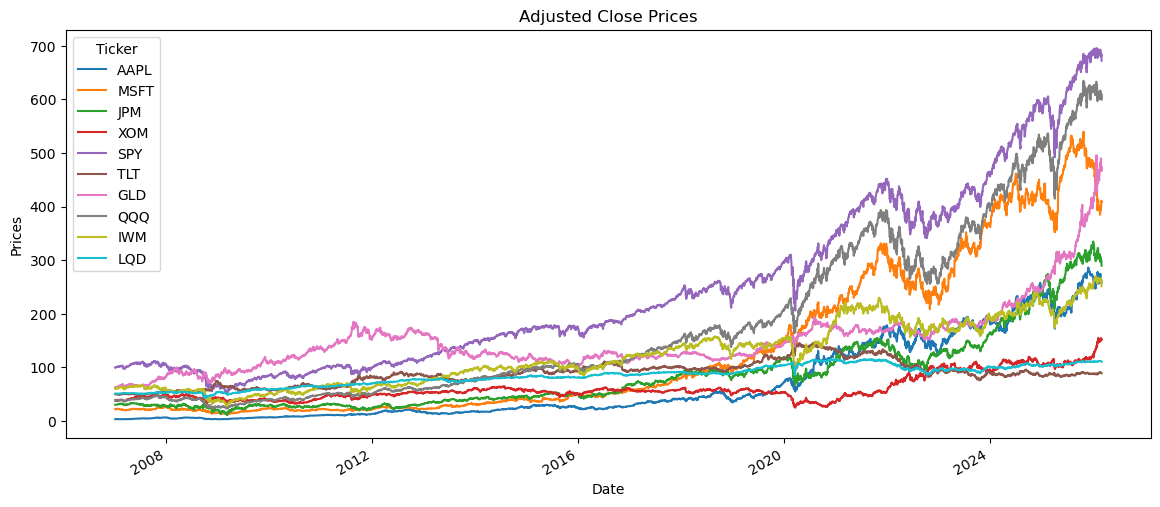

In [28]:
engine.prices.plot(figsize = (14,6),title = "Adjusted Close Prices")
plt.ylabel("Prices")
plt.xlabel("Date")
plt.show()

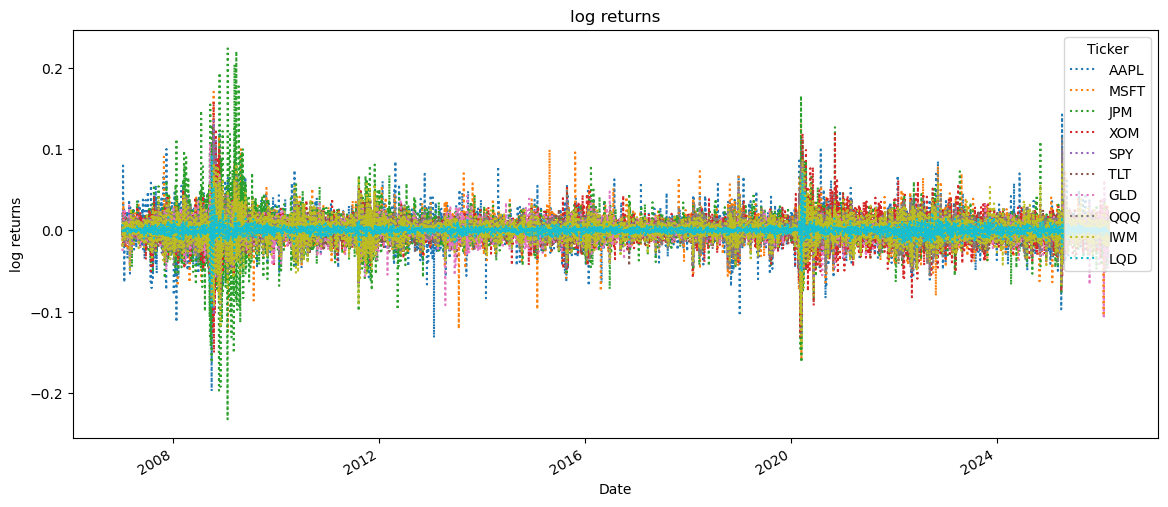

In [29]:
engine.log_returns.plot(figsize = (14,6),title = "log returns",linestyle = ":")
plt.ylabel("log returns")
plt.xlabel("Date")
plt.show()

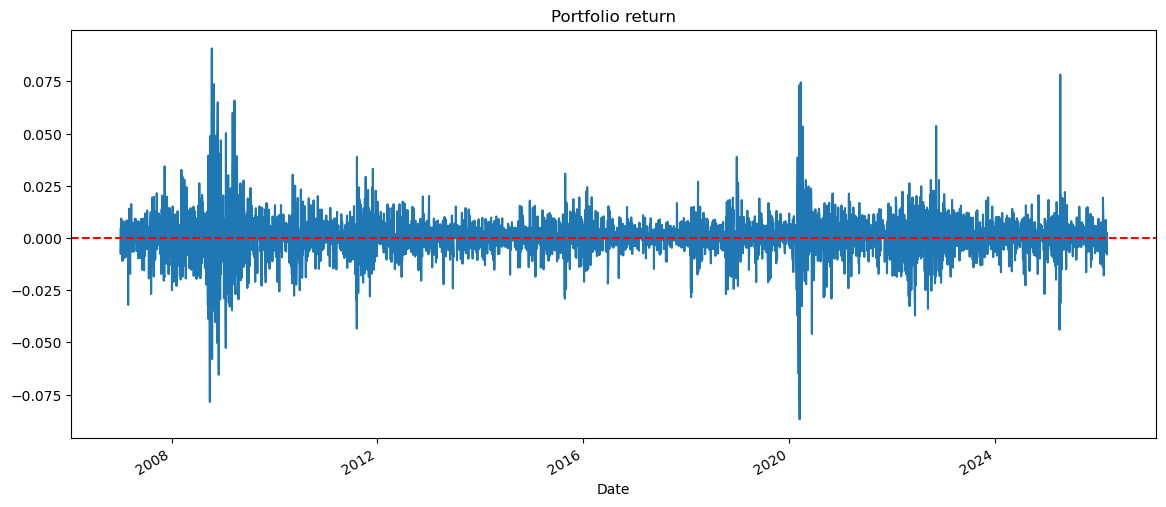

In [30]:
engine.portfolio.portfolio_return.plot(figsize = (14,6),title = "Portfolio return")
plt.axhline(0, linestyle="--",color = "red")
plt.show()

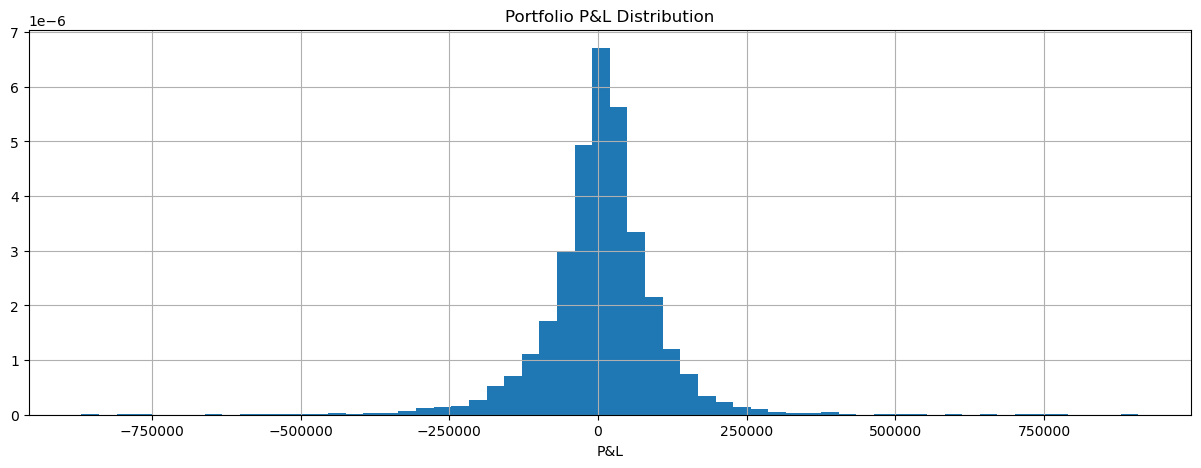

In [31]:
engine.portfolio["portfolio_pnl"].hist( figsize = (15,5),bins = 60,density = True)
plt.title("Portfolio P&L Distribution")
plt.xlabel("P&L")
plt.show()

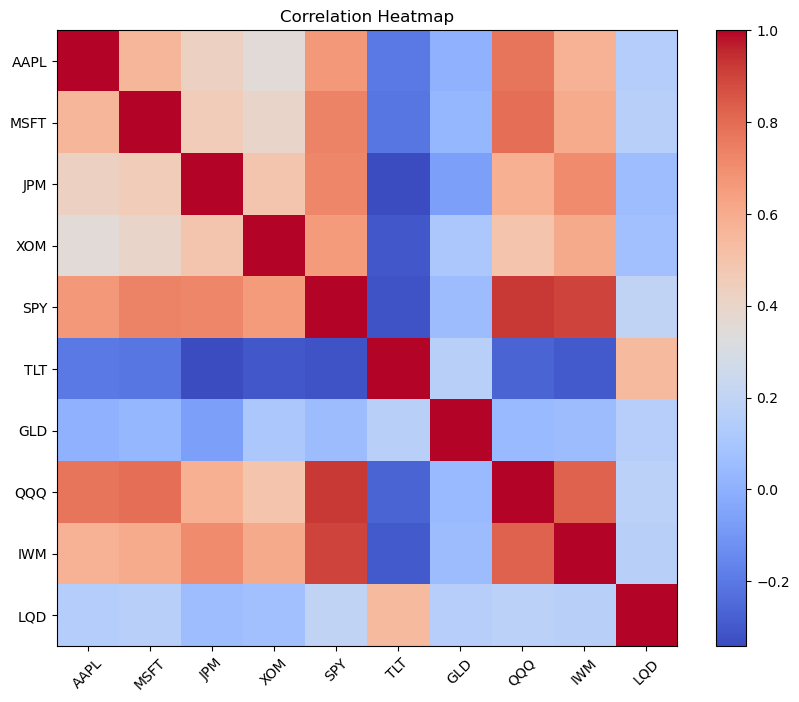

In [32]:
corr = engine.log_returns.corr()
plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap="coolwarm", aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlation Heatmap")
plt.show()

# Baseline historical simulation

In [33]:
pnl = engine.portfolio["portfolio_pnl"]

hs_result = pd.DataFrame({"Metrics":["VaR 95","VaR 99","ES 95","ES 99"],
                          "Values": [var_from_pnl(pnl,0.95),var_from_pnl(pnl,0.99),es_from_pnl(pnl,0.95),es_from_pnl(pnl,0.99)]})
print(hs_result)

  Metrics         Values
0  VaR 95  148042.453150
1  VaR 99  279855.403865
2   ES 95 -235315.073545
3   ES 99 -399690.120640


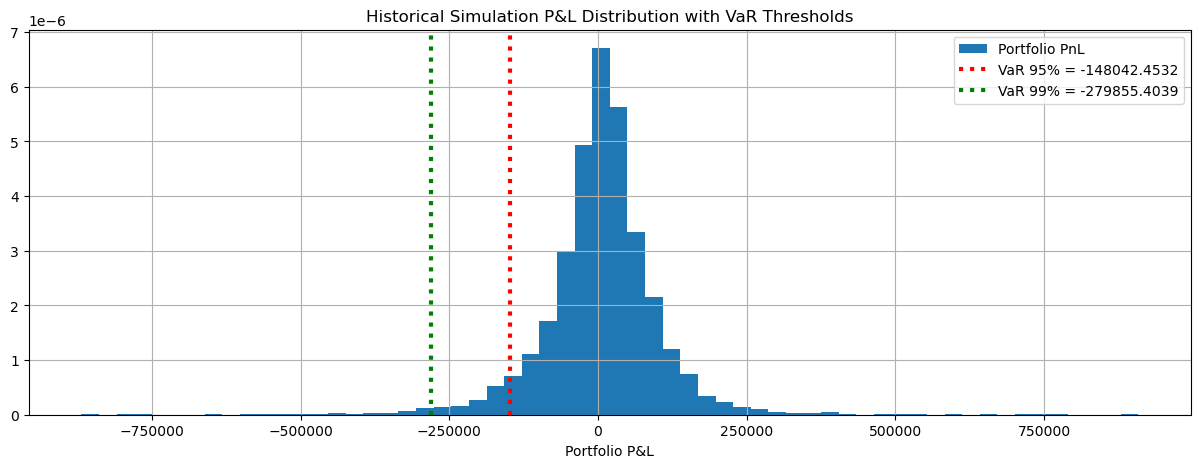

In [34]:
var95 = var_from_pnl(pnl, 0.95)
var99 = var_from_pnl(pnl, 0.99)

plt.figure(figsize = (15,5))
plt.hist(engine.portfolio.portfolio_pnl, bins = 60,density = True,label = "Portfolio PnL")
plt.axvline(-var95,color = "red",linestyle = ":",linewidth = 3,label = f"VaR 95% = {round(-var95,4)}")
plt.axvline(-var99,color = "green",linestyle = ":",linewidth = 3,label = f"VaR 99% = {round(-var99,4)}")
plt.title("Historical Simulation P&L Distribution with VaR Thresholds")
plt.xlabel("Portfolio P&L")
plt.legend()
plt.grid()
plt.show()

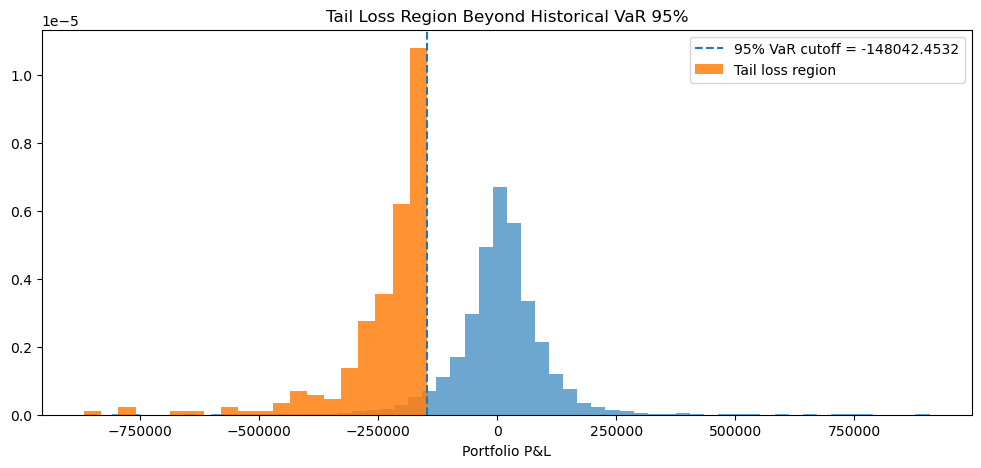

In [35]:
cutoff_95 = -var95
tail_95 = pnl[pnl <= cutoff_95]

plt.figure(figsize=(12, 5))
plt.hist(pnl, bins=60, alpha=0.65, density=True)
plt.axvline(cutoff_95, linestyle="--", label=f"95% VaR cutoff = {round(cutoff_95,4)}")
plt.hist(tail_95, bins=20, alpha=0.85, density=True, label="Tail loss region")
plt.title("Tail Loss Region Beyond Historical VaR 95%")
plt.xlabel("Portfolio P&L")
plt.legend()
plt.show()

# BOOTSTRAPPED HISTORICAL SIMULATION

In [36]:
def bootstrap_summary_table(pnl: pd.Series, n_bootstrap: int, sample_size: int):
    rows = []
    for c in [0.95,0.99]:
        bt = bootstrap_var_es(pnl,c,n_bootstrap,sample_size,random_state=42)
        var_summary = summarize_bootstrap_metric(bt["VaR"])
        es_summary = summarize_bootstrap_metric(bt["ES"])
        rows.append({
            "Confidence": c,
            "Sample Size": sample_size,
            "Bootstraps": n_bootstrap,
            "Mean VaR": var_summary["mean"],
            "Std VaR": var_summary["std"],
            "VaR CI Lower": var_summary["ci_lower"],
            "VaR CI Upper": var_summary["ci_upper"],
            "Mean ES": es_summary["mean"],
            "Std ES": es_summary["std"],
            "ES CI Lower": es_summary["ci_lower"],
            "ES CI Upper": es_summary["ci_upper"],
        })
    return pd.DataFrame(rows)

In [37]:
summary_100 = bootstrap_summary_table(pnl, n_bootstrap=6, sample_size=100)
summary_200 = bootstrap_summary_table(pnl, n_bootstrap=6, sample_size=200)

In [38]:
summary_100

,Confidence,Sample Size,Bootstraps,Mean VaR,Std VaR,VaR CI Lower,VaR CI Upper,Mean ES,Std ES,ES CI Lower,ES CI Upper
0,0.95,100,6,138313.295381,28974.321388,105350.212867,176357.779766,-224023.859392,46871.780757,-284824.095337,-170040.143823
1,0.99,100,6,249130.056787,54206.683616,186730.848125,324228.100364,-326502.540849,125118.803223,-510991.380482,-193234.866009


In [39]:
summary_200

,Confidence,Sample Size,Bootstraps,Mean VaR,Std VaR,VaR CI Lower,VaR CI Upper,Mean ES,Std ES,ES CI Lower,ES CI Upper
0,0.95,200,6,142471.104821,22152.288241,115605.234785,174517.548580,-237139.354204,35858.482112,-290708.002215,-200607.759716
1,0.99,200,6,251343.749764,34909.176689,195161.728598,288401.943724,-390116.921243,112056.080647,-578035.829284,-304021.147685


In [40]:
#Convergence experiment 6,12,24,36 bootstrap

In [41]:
def bootstrap_convergence_experiment(pnl:pd.Series, bootstrap_count = (6,12,24,36), sample_size = (100,200)):
    records = []
    for B in bootstrap_count:
        for m in sample_size:
            for c in [0.95,0.99]:
                bt = bootstrap_var_es(pnl, confidence=c, n_bootstrap=B, sample_size=m, random_state=42)
                var_stats = summarize_bootstrap_metric(bt["VaR"])
                es_stats = summarize_bootstrap_metric(bt["ES"])

                records.append({
                    "Bootstraps": B,
                    "Sample Size": m,
                    "Confidence": c,
                    "Mean VaR": var_stats["mean"],
                    "Std VaR": var_stats["std"],
                    "VaR CI Width": var_stats["ci_upper"] - var_stats["ci_lower"],
                    "Mean ES": es_stats["mean"],
                    "Std ES": es_stats["std"],
                    "ES CI Width": es_stats["ci_upper"] - es_stats["ci_lower"],
                })
    return pd.DataFrame(records)

In [42]:
bootsstrap_convergence_exp = bootstrap_convergence_experiment(pnl)
bootsstrap_convergence_exp

,Bootstraps,Sample Size,Confidence,Mean VaR,Std VaR,VaR CI Width,Mean ES,Std ES,ES CI Width
0,6,100,0.95,138313.295381,28974.321388,71007.566899,-224023.859392,46871.780757,114783.951513
1,6,100,0.99,249130.056787,54206.683616,137497.252239,-326502.540849,125118.803223,317756.514473
2,6,200,0.95,142471.104821,22152.288241,58912.313795,-237139.354204,35858.482112,90100.242500
3,6,200,0.99,251343.749764,34909.176689,93240.215127,-390116.921243,112056.080647,274014.681599
4,12,100,0.95,138110.284962,23769.960197,73224.301240,-235439.008302,50905.030828,149232.633939
5,12,100,0.99,250447.672785,51154.352426,161561.253925,-370386.896995,142892.661329,426808.847784
6,12,200,0.95,150176.448354,30128.207010,88459.540516,-239540.573907,41461.820788,126729.843138
7,12,200,0.99,258198.561094,45412.548777,146832.437397,-397751.990371,128678.385016,391628.291386
8,24,100,0.95,145219.348627,32760.770157,98649.641471,-238800.889335,52245.269665,164742.612709
9,24,100,0.99,248633.586798,50221.902621,165878.818666,-384669.621674,162552.594093,529171.922461


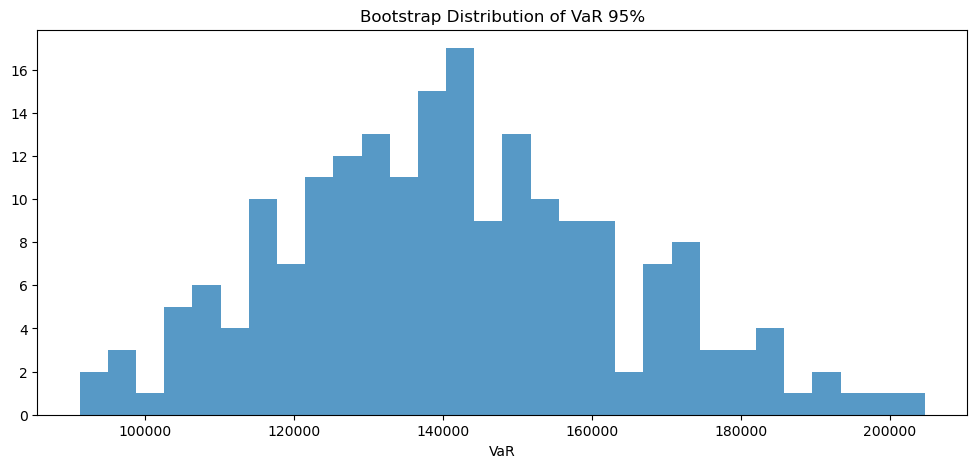

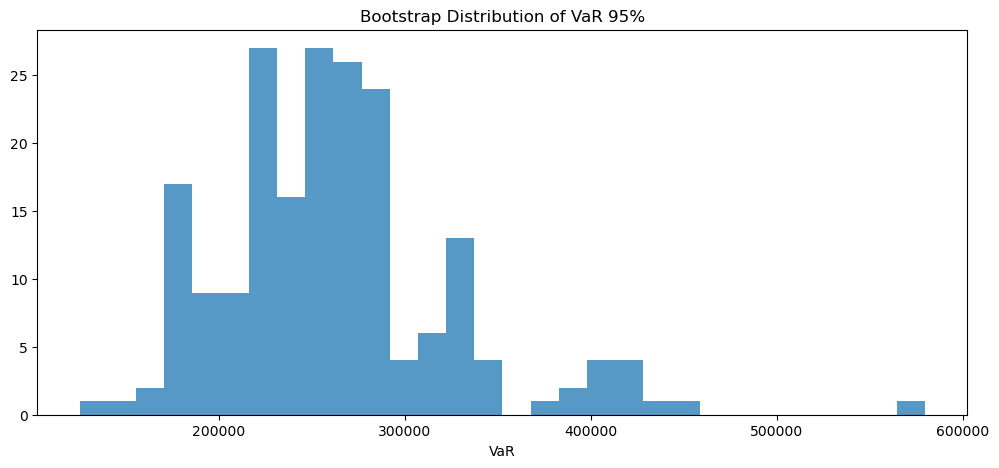

In [43]:
bt_95 = bootstrap_var_es(pnl, confidence=0.95, n_bootstrap=200, sample_size=200, random_state=42)
bt_99 = bootstrap_var_es(pnl, confidence=0.99, n_bootstrap=200, sample_size=200, random_state=42)

plt.figure(figsize=(12, 5))
plt.hist(bt_95["VaR"], bins=30, alpha=0.75)
plt.title("Bootstrap Distribution of VaR 95%")
plt.xlabel("VaR")
plt.show()

plt.figure(figsize=(12, 5))
plt.hist(bt_99["VaR"], bins=30, alpha=0.75)
plt.title("Bootstrap Distribution of VaR 95%")
plt.xlabel("VaR")
plt.show()

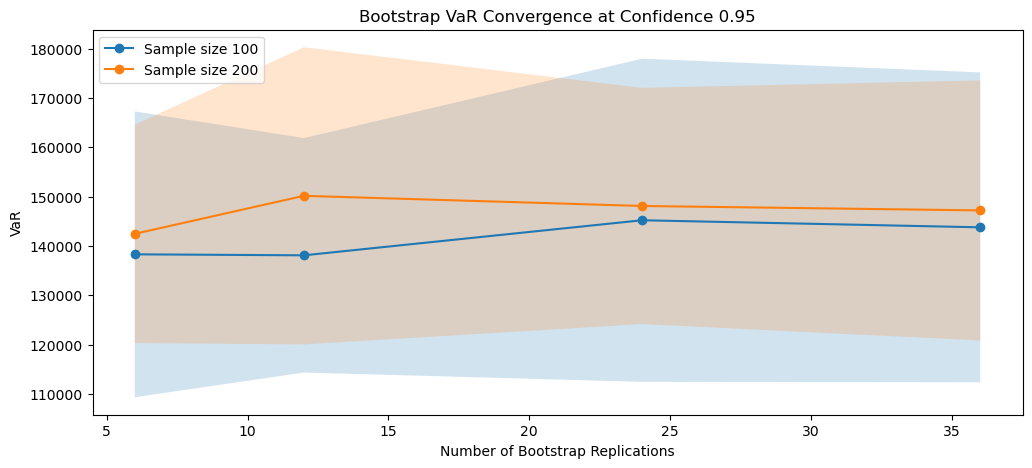

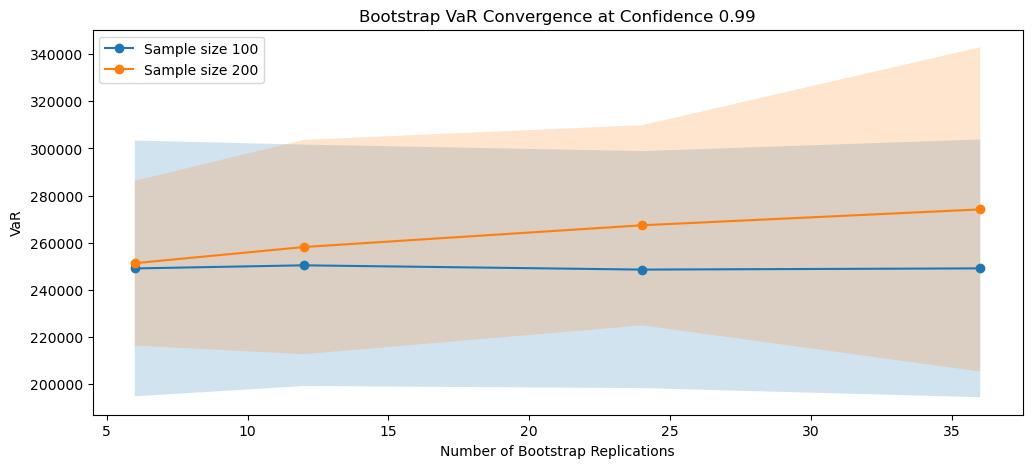

In [44]:
for c in [0.95, 0.99]:
    subset = bootsstrap_convergence_exp[bootsstrap_convergence_exp["Confidence"] == c]

    plt.figure(figsize=(12, 5))
    for m in [100, 200]:
        s = subset[subset["Sample Size"] == m]
        plt.plot(s["Bootstraps"], s["Mean VaR"], marker="o", label=f"Sample size {m}")
        plt.fill_between(
            s["Bootstraps"],
            s["Mean VaR"] - s["Std VaR"],
            s["Mean VaR"] + s["Std VaR"],
            alpha=0.2
        )
    plt.title(f"Bootstrap VaR Convergence at Confidence {c}")
    plt.xlabel("Number of Bootstrap Replications")
    plt.ylabel("VaR")
    plt.legend()
    plt.show()

# Exponentially weighted historical simulations

In [45]:
lam = engine.lambda_mle
ewhs_95 = ewhs_var_es(pnl,lam,0.95)
ewhs_99 = ewhs_var_es(pnl,lam,0.99)

print("EWHS VaR 95%:", ewhs_95["VaR"])
print("EWHS ES 95% :", ewhs_95["ES"])
print("EWHS VaR 99%:", ewhs_99["VaR"])
print("EWHS ES 99% :", ewhs_99["ES"])

EWHS VaR 95%: -124576.35837994264
EWHS ES 95% : 155644.37672258617
EWHS VaR 99%: -180145.0973711875
EWHS ES 99% : 179537.05471516112


In [46]:
weight_table = pd.concat(
    [pnl.dropna().rename("pnl"), ewhs_95["weights"]],
    axis=1
).sort_values("pnl")

weight_table["cum_weight"] = weight_table["exp_weight"].cumsum()
print(weight_table.head(20))

                      pnl     exp_weight    cum_weight
Date                                                  
2020-03-16 -868202.489047   5.827979e-41  5.827979e-41
2008-09-29 -785093.610877  6.830851e-116  5.827979e-41
2020-03-12 -776272.834765   5.170764e-41  1.099874e-40
2008-12-01 -654671.198908  9.498759e-115  1.099874e-40
2020-03-09 -650273.437616   4.321254e-41  1.532000e-40
2008-10-15 -579783.553173  1.400408e-115  1.532000e-40
2020-03-18 -549190.376445   6.568727e-41  2.188872e-40
2009-01-20 -526479.364189  6.840076e-114  2.188872e-40
2008-11-20 -502703.615380  6.634024e-115  2.188872e-40
2020-06-11 -459468.155145   2.240773e-39  2.459660e-39
2008-11-19 -449399.489043  6.248782e-115  2.459660e-39
2025-04-04 -439175.735772   6.140157e-08  6.140157e-08
2011-08-08 -433821.567802   3.477394e-97  6.140157e-08
2008-10-09 -431640.071512  1.102371e-115  6.140157e-08
2008-10-07 -429671.380161  9.780581e-116  6.140157e-08
2025-04-03 -415739.686291   5.783595e-08  1.192375e-07
2008-11-05

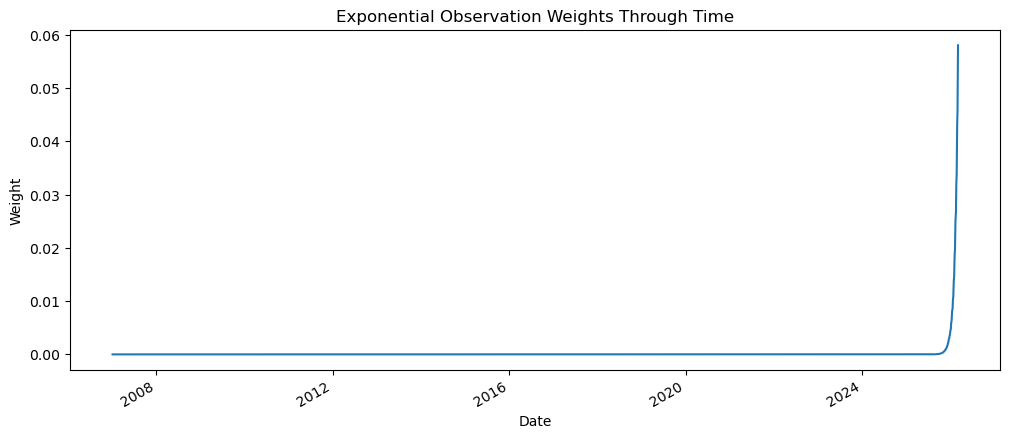

In [47]:
ewhs_95["weights"].plot(figsize=(12, 5), title="Exponential Observation Weights Through Time")
plt.ylabel("Weight")
plt.show()

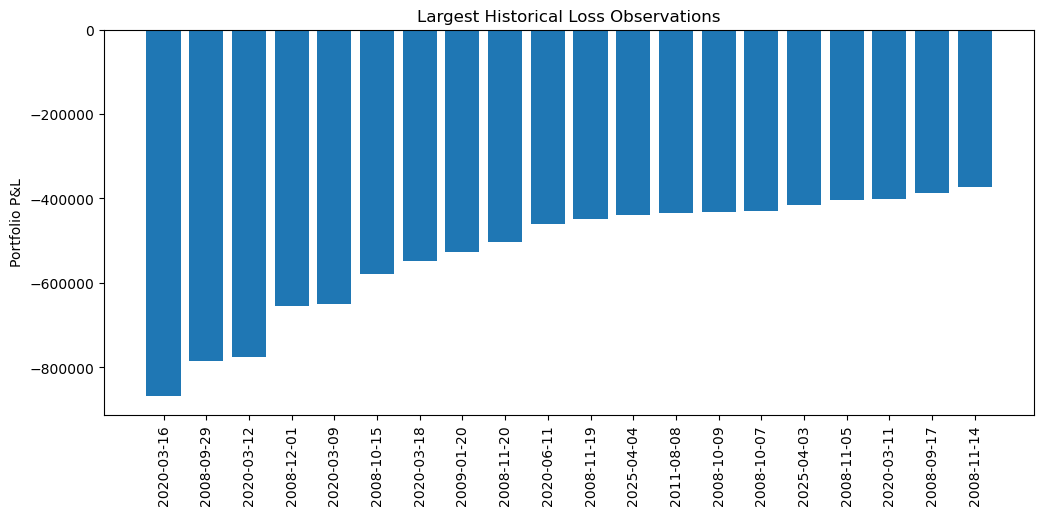

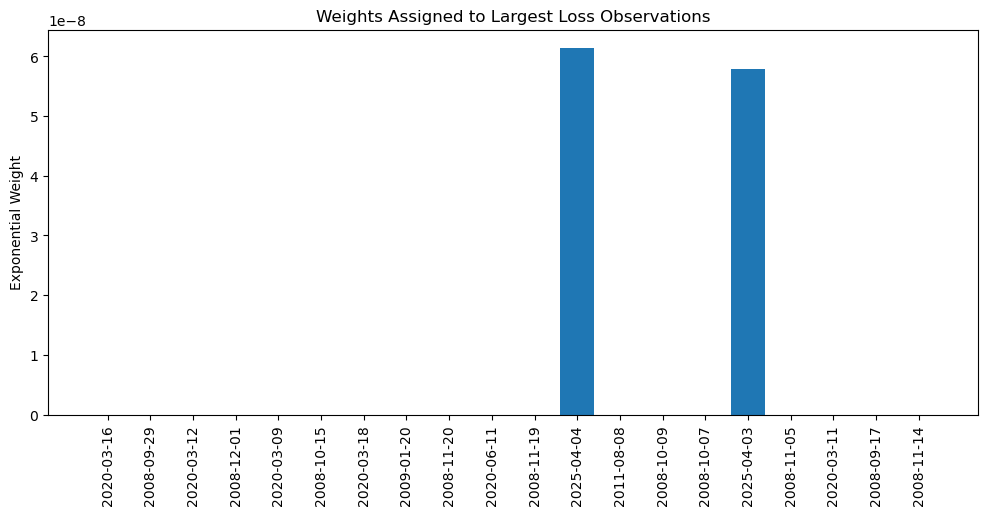

In [48]:
largest_losses = weight_table.head(20)

plt.figure(figsize=(12, 5))
plt.bar(largest_losses.index.astype(str), largest_losses["pnl"])
plt.xticks(rotation=90)
plt.title("Largest Historical Loss Observations")
plt.ylabel("Portfolio P&L")
plt.show()

plt.figure(figsize=(12, 5))
plt.bar(largest_losses.index.astype(str), largest_losses["exp_weight"])
plt.xticks(rotation=90)
plt.title("Weights Assigned to Largest Loss Observations")
plt.ylabel("Exponential Weight")
plt.show()

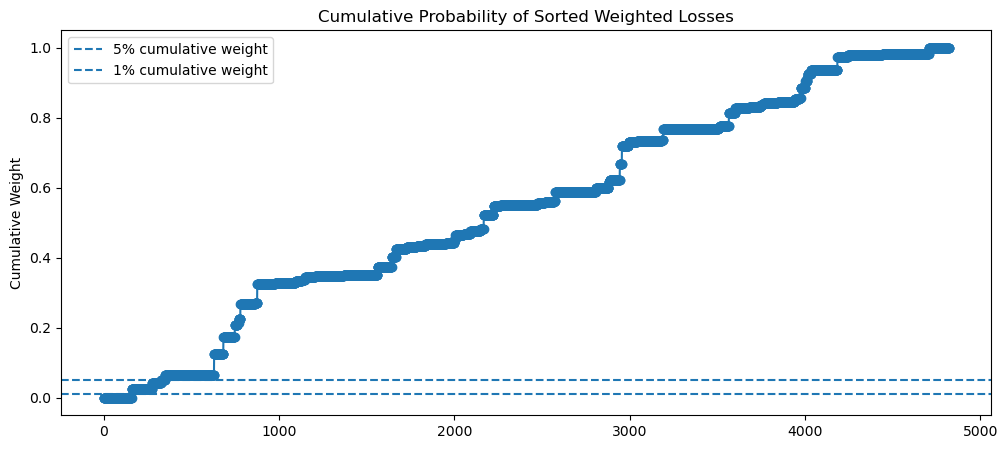

In [49]:
var95_cutoff = 1 - 0.95
var99_cutoff = 1 - 0.99

plt.figure(figsize=(12, 5))
plt.plot(weight_table["cum_weight"].values, marker="o")
plt.axhline(var95_cutoff, linestyle="--", label="5% cumulative weight")
plt.axhline(var99_cutoff, linestyle="--", label="1% cumulative weight")
plt.title("Cumulative Probability of Sorted Weighted Losses")
plt.ylabel("Cumulative Weight")
plt.legend()
plt.show()

# VOLATILITY WEIGHTED HISTORICAL SIMULATION

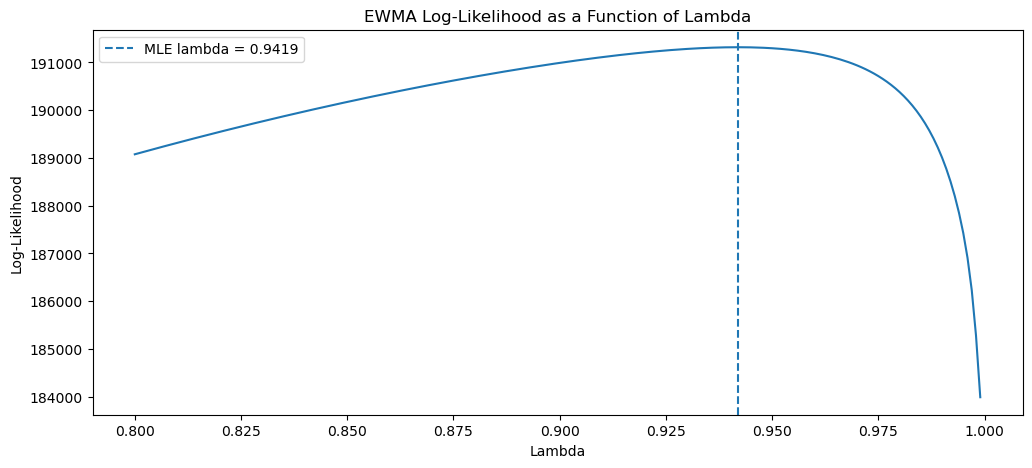

In [50]:
lambda_grid = np.linspace(0.80, 0.999, 200)
loglik_grid = [-ewma_neg_loglik(lam, engine.log_returns) for lam in lambda_grid]

plt.figure(figsize=(12, 5))
plt.plot(lambda_grid, loglik_grid)
plt.axvline(engine.lambda_mle, linestyle="--", label=f"MLE lambda = {engine.lambda_mle:.4f}")
plt.title("EWMA Log-Likelihood as a Function of Lambda")
plt.xlabel("Lambda")
plt.ylabel("Log-Likelihood")
plt.legend()
plt.show()

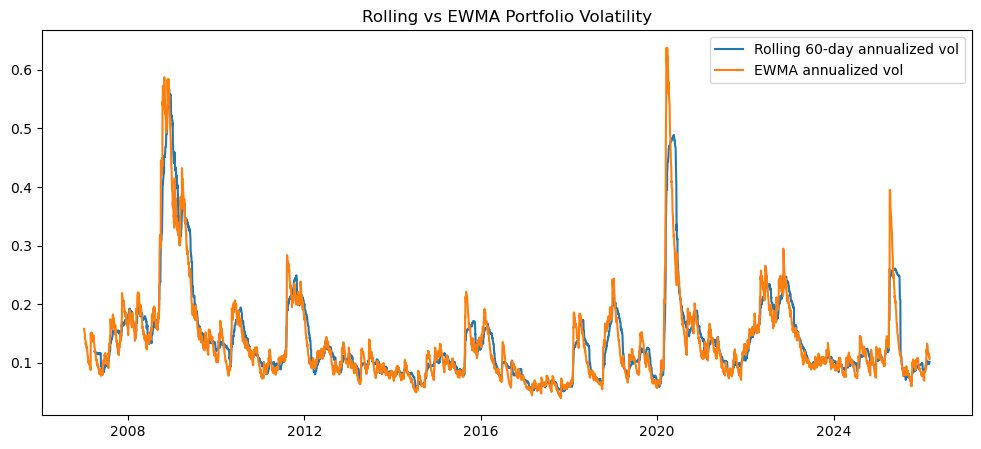

In [51]:
portfolio_returns = engine.portfolio["portfolio_return"]
rolling_vol = portfolio_returns.rolling(60).std() * np.sqrt(252)
ewma_vol = ewma_volatility(portfolio_returns, engine.lambda_mle) * np.sqrt(252)

plt.figure(figsize=(12, 5))
plt.plot(rolling_vol.index, rolling_vol, label="Rolling 60-day annualized vol")
plt.plot(ewma_vol.index, ewma_vol, label="EWMA annualized vol")
plt.title("Rolling vs EWMA Portfolio Volatility")
plt.legend()
plt.show()

In [52]:
scaled_log_returns, sigma_df = volatility_scale_returns(engine.log_returns, engine.lambda_mle)
scaled_simple_returns = np.exp(scaled_log_returns) - 1.0
scaled_portfolio_pnl = spec.portfolio_value * (scaled_simple_returns @ spec.weights)

vw_results = pd.DataFrame({
    "Metric": ["VaR 95%", "VaR 99%", "ES 95%", "ES 99%"],
    "Value": [
        var_from_pnl(scaled_portfolio_pnl, 0.95),
        var_from_pnl(scaled_portfolio_pnl, 0.99),
        es_from_pnl(scaled_portfolio_pnl, 0.95),
        es_from_pnl(scaled_portfolio_pnl, 0.99),
    ]
})

print(vw_results)

    Metric          Value
0  VaR 95%  138169.976446
1  VaR 99%  235104.278664
2   ES 95% -199619.347272
3   ES 99% -303110.733403


# CORRELATION WEIGHTED HISTORICAL SIMULATION

In [58]:
corr_adj_log_returns, cov_series, current_cov = correlation_adjust_returns(engine.log_returns, engine.lambda_mle)
corr_adj_simple_returns = np.exp(corr_adj_log_returns) - 1.0
corr_adj_portfolio_pnl = spec.portfolio_value * (corr_adj_simple_returns @ spec.weights)

In [59]:
current_corr = cov_to_corr(current_cov)
print(current_cov)
print(current_corr)

Ticker      AAPL      MSFT       JPM       XOM       SPY       TLT       GLD  \
Ticker                                                                         
AAPL    0.000272  0.000025  0.000115 -0.000017  0.000065 -0.000023 -0.000051   
MSFT    0.000025  0.000422  0.000091 -0.000081  0.000057 -0.000029 -0.000027   
JPM     0.000115  0.000091  0.000285 -0.000048  0.000077 -0.000008 -0.000010   
XOM    -0.000017 -0.000081 -0.000048  0.000280 -0.000007 -0.000010  0.000196   
SPY     0.000065  0.000057  0.000077 -0.000007  0.000060 -0.000004  0.000029   
TLT    -0.000023 -0.000029 -0.000008 -0.000010 -0.000004  0.000028 -0.000007   
GLD    -0.000051 -0.000027 -0.000010  0.000196  0.000029 -0.000007  0.000634   
QQQ     0.000068  0.000086  0.000076 -0.000017  0.000078 -0.000008  0.000051   
IWM     0.000084  0.000060  0.000136 -0.000006  0.000085 -0.000004  0.000091   
LQD    -0.000004 -0.000010  0.000004 -0.000007  0.000003  0.000010 -0.000003   

Ticker       QQQ       IWM       LQD  


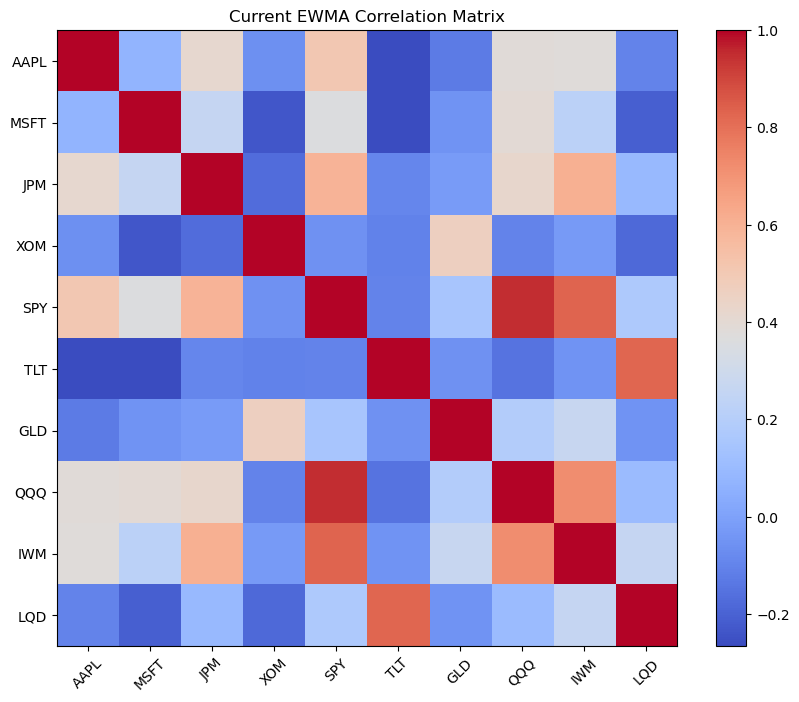

In [60]:
plt.figure(figsize=(10, 8))
plt.imshow(current_corr, cmap="coolwarm", aspect="auto")
plt.colorbar()
plt.xticks(range(len(current_corr.columns)), current_corr.columns, rotation=45)
plt.yticks(range(len(current_corr.index)), current_corr.index)
plt.title("Current EWMA Correlation Matrix")
plt.show()

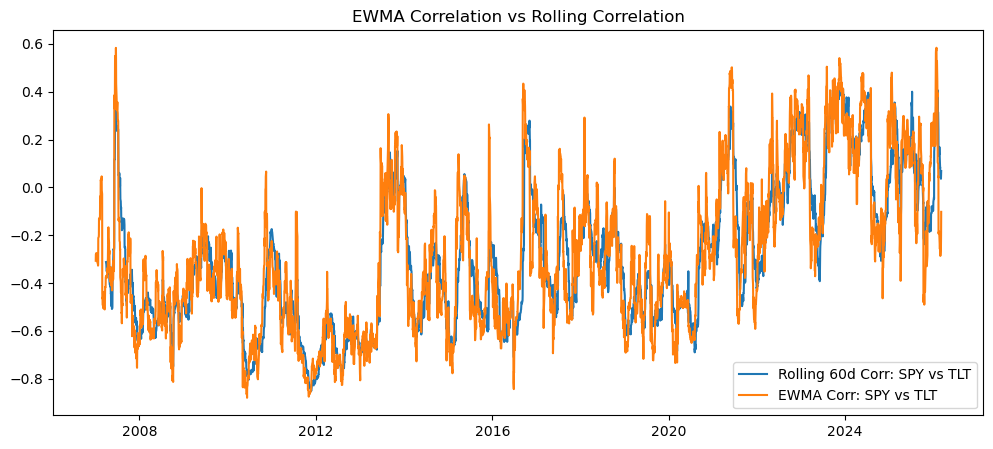

In [61]:
pair = ("SPY", "TLT") if {"SPY", "TLT"}.issubset(set(spec.tickers)) else (spec.tickers[0], spec.tickers[1])

ewma_pair_corr = pd.Series({
    date: cov_to_corr(cov).loc[pair[0], pair[1]]
    for date, cov in cov_series.items()
}, name="EWMA Corr")

rolling_pair_corr = engine.log_returns[pair[0]].rolling(60).corr(engine.log_returns[pair[1]])

plt.figure(figsize=(12, 5))
plt.plot(rolling_pair_corr.index, rolling_pair_corr, label=f"Rolling 60d Corr: {pair[0]} vs {pair[1]}")
plt.plot(ewma_pair_corr.index, ewma_pair_corr, label=f"EWMA Corr: {pair[0]} vs {pair[1]}")
plt.title("EWMA Correlation vs Rolling Correlation")
plt.legend()
plt.show()

In [63]:
comparison_cw = pd.DataFrame({
    "Model": ["Historical Simulation", "Volatility Weighted HS", "Correlation Weighted HS"],
    "VaR 95%": [
        var_from_pnl(pnl, 0.95),
        var_from_pnl(scaled_portfolio_pnl, 0.95),
        var_from_pnl(corr_adj_portfolio_pnl, 0.95)
    ],
    "VaR 99%": [
        var_from_pnl(pnl, 0.99),
        var_from_pnl(scaled_portfolio_pnl, 0.99),
        var_from_pnl(corr_adj_portfolio_pnl, 0.99)
    ],
    "ES 95%": [
        es_from_pnl(pnl, 0.95),
        es_from_pnl(scaled_portfolio_pnl, 0.95),
        es_from_pnl(corr_adj_portfolio_pnl, 0.95)
    ],
    "ES 99%": [
        es_from_pnl(pnl, 0.99),
        es_from_pnl(scaled_portfolio_pnl, 0.99),
        es_from_pnl(corr_adj_portfolio_pnl, 0.99)
    ]
})

comparison_cw

,Model,VaR 95%,VaR 99%,ES 95%,ES 99%
0,Historical Simulation,148042.453150,279855.403865,-235315.073545,-399690.120640
1,Volatility Weighted HS,138169.976446,235104.278664,-199619.347272,-303110.733403
2,Correlation Weighted HS,104474.217840,150497.898972,-134627.667063,-176196.126242


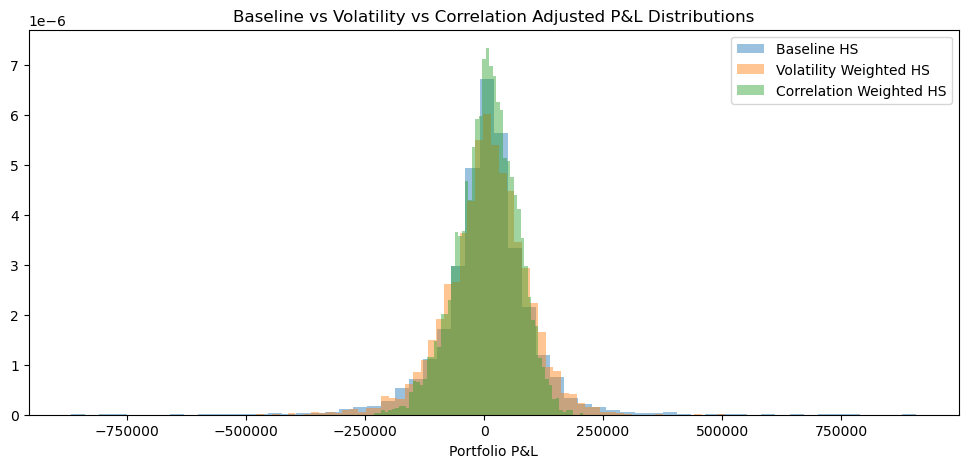

In [64]:
plt.figure(figsize=(12, 5))
plt.hist(pnl, bins=60, alpha=0.45, density=True, label="Baseline HS")
plt.hist(scaled_portfolio_pnl, bins=60, alpha=0.45, density=True, label="Volatility Weighted HS")
plt.hist(corr_adj_portfolio_pnl, bins=60, alpha=0.45, density=True, label="Correlation Weighted HS")
plt.title("Baseline vs Volatility vs Correlation Adjusted P&L Distributions")
plt.xlabel("Portfolio P&L")
plt.legend()
plt.show()

# VaR Backtesting

In [69]:
def forecast_var_from_train(train_log_returns: pd.DataFrame, spec: Portfolio_Spec, model: str, confidence: float, lam: float, mc_sims: int = 10_000) -> float:
    simple = np.exp(train_log_returns) - 1.0
    pnl_train = spec.portfolio_value * (simple @ spec.weights)

    if model == "Historical Simulation":
        return var_from_pnl(pnl_train, confidence)

    elif model == "Exponentially Weighted HS":
        return ewhs_var_es(pnl_train, lam=lam, confidence=confidence)["VaR"]

    elif model == "Volatility Weighted HS":
        scaled_log, _ = volatility_scale_returns(train_log_returns, lam)
        scaled_simple = np.exp(scaled_log) - 1.0
        scaled_pnl = spec.portfolio_value * (scaled_simple @ spec.weights)
        return var_from_pnl(scaled_pnl, confidence)

    elif model == "Correlation Weighted HS":
        adj_log, _, _ = correlation_adjust_returns(train_log_returns, lam)
        adj_simple = np.exp(adj_log) - 1.0
        adj_pnl = spec.portfolio_value * (adj_simple @ spec.weights)
        return var_from_pnl(adj_pnl, confidence)

    elif model == "Delta-Normal VaR":
        return delta_normal_var_es(simple, spec.weights, spec.portfolio_value, confidence)["VaR"]

    elif model == "Monte Carlo VaR":
        return monte_carlo_var_es(simple, spec.weights, spec.portfolio_value, confidence, n_sim=mc_sims)["VaR"]

    else:
        raise ValueError(f"Unknown model: {model}")


def rolling_var_backtest(log_returns: pd.DataFrame, spec: Portfolio_Spec, model: str, confidence: float = 0.99, window: int = 500, refit_every: int = 1, mc_sims: int = 5000) -> pd.DataFrame:
    lam, _ = estimate_lambda_mle(log_returns)
    simple_all = np.exp(log_returns) - 1.0
    realized_pnl_all = spec.portfolio_value * (simple_all @ spec.weights)

    records = []
    cached_var = None

    for t in range(window, len(log_returns)):
        if ((t - window) % refit_every == 0) or (cached_var is None):
            train = log_returns.iloc[t - window:t]
            cached_var = forecast_var_from_train(train, spec, model, confidence, lam=lam, mc_sims=mc_sims)

        date = log_returns.index[t]
        realized_pnl = realized_pnl_all.iloc[t]
        breach = realized_pnl < -cached_var

        records.append({
            "Date": date,
            "VaR": cached_var,
            "Realized P&L": realized_pnl,
            "Breach": int(breach)
        })

    return pd.DataFrame(records).set_index("Date")

In [70]:
models_to_backtest = [
    "Historical Simulation",
    "Exponentially Weighted HS",
    "Volatility Weighted HS",
    "Correlation Weighted HS",
    "Delta-Normal VaR"
]

backtest_results = {}
for m in models_to_backtest:
    bt = rolling_var_backtest(engine.log_returns, spec, model=m, confidence=0.99, window=500, refit_every=5)
    backtest_results[m] = bt

In [71]:
backtest_summary = []

for m, bt in backtest_results.items():
    uc = kupiec_test(bt["Breach"], alpha=0.01)
    cc = christoffersen_test(bt["Breach"], alpha=0.01)

    backtest_summary.append({
        "Model": m,
        "Failures": uc["failures"],
        "Failure Rate": uc["failure_rate"],
        "Expected Failures": uc["expected_failures"],
        "Kupiec LR": uc["LR_uc"],
        "Kupiec p-value": uc["p_value"],
        "Christoffersen LR_ind": cc["LR_ind"],
        "Christoffersen p_ind": cc["p_ind"],
        "Christoffersen LR_cc": cc["LR_cc"],
        "Christoffersen p_cc": cc["p_cc"]
    })

backtest_summary = pd.DataFrame(backtest_summary)
print(backtest_summary)

                       Model  Failures  Failure Rate  Expected Failures  \
0      Historical Simulation        50      0.011566              43.23   
1  Exponentially Weighted HS      4230      0.978487              43.23   
2     Volatility Weighted HS        50      0.011566              43.23   
3    Correlation Weighted HS       111      0.025677              43.23   
4           Delta-Normal VaR        84      0.019431              43.23   

      Kupiec LR  Kupiec p-value  Christoffersen LR_ind  Christoffersen p_ind  \
0      1.019546    3.126268e-01              23.819498              0.000001   
1  38063.550730    0.000000e+00               1.632292              0.201386   
2      1.019546    3.126268e-01              13.546026              0.000233   
3     74.883847    0.000000e+00               6.715969              0.009555   
4     30.449016    3.427572e-08              21.291210              0.000004   

   Christoffersen LR_cc  Christoffersen p_cc  
0             24.8390

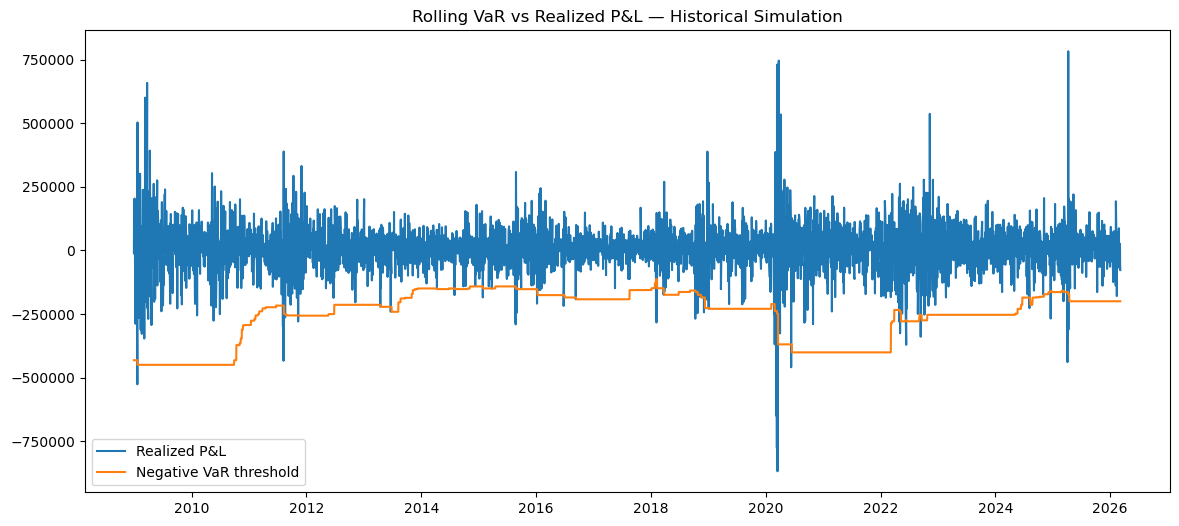

In [72]:
model_to_plot = "Historical Simulation"
bt = backtest_results[model_to_plot]

plt.figure(figsize=(14, 6))
plt.plot(bt.index, bt["Realized P&L"], label="Realized P&L")
plt.plot(bt.index, -bt["VaR"], label="Negative VaR threshold")
plt.title(f"Rolling VaR vs Realized P&L — {model_to_plot}")
plt.legend()
plt.show()

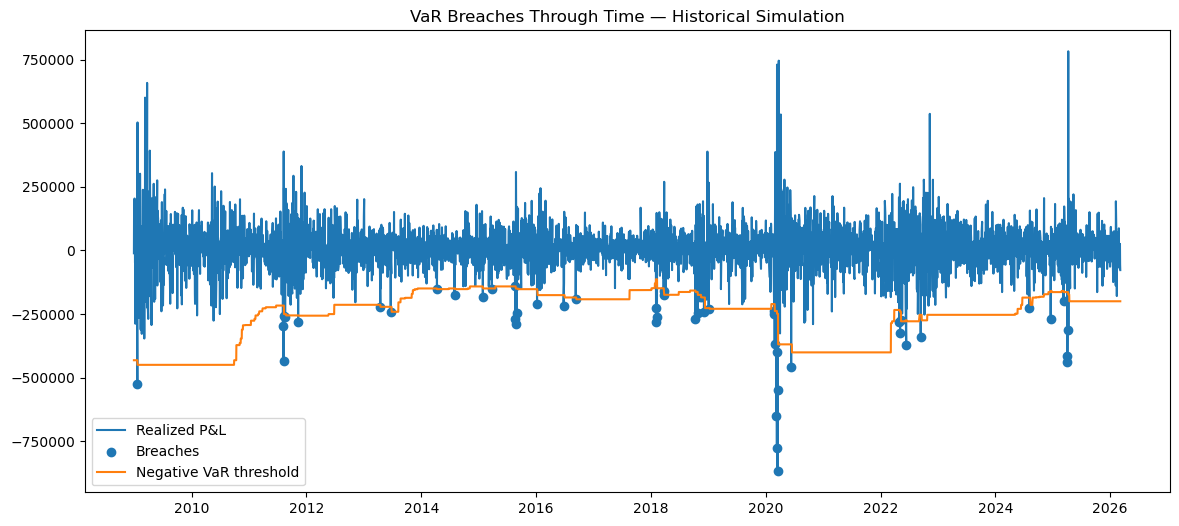

In [73]:
breaches = bt[bt["Breach"] == 1]

plt.figure(figsize=(14, 6))
plt.plot(bt.index, bt["Realized P&L"], label="Realized P&L")
plt.scatter(breaches.index, breaches["Realized P&L"], label="Breaches")
plt.plot(bt.index, -bt["VaR"], label="Negative VaR threshold")
plt.title(f"VaR Breaches Through Time — {model_to_plot}")
plt.legend()
plt.show()

# Report Generator

In [75]:
def generate_risk_report(
    spec: Portfolio_Spec,
    model_comparison: pd.DataFrame,
    backtest_summary: pd.DataFrame,
    risk_contrib: pd.DataFrame,
    scenario_df: pd.DataFrame,
    stress_df: pd.DataFrame
) -> str:
    conservative_row = (
        model_comparison[model_comparison["Confidence"] == 0.99]
        .sort_values("VaR", ascending=False)
        .iloc[0]
    )

    top_risk_asset = risk_contrib["% Contribution"].idxmax()

    report = f"""
# DAILY MARKET RISK REPORT

## 1. Portfolio Overview
- Tickers: {", ".join(spec.tickers)}
- Weights: {np.round(spec.weights, 4).tolist()}
- Portfolio Value: ${spec.portfolio_value:,.0f}

## 2. Model Comparison
{model_comparison.to_string(index=False)}

## 3. Most Conservative Model at 99%
- Model: {conservative_row['Model']}
- VaR 99%: {conservative_row['VaR']:,.2f}
- ES 99%: {conservative_row['ES']:,.2f}

## 4. Backtesting Summary
{backtest_summary.to_string(index=False)}

## 5. Risk Contributions
Top contributor to VaR: {top_risk_asset}

{risk_contrib.to_string()}

## 6. Scenario Analysis
{scenario_df.to_string(index=False)}

## 7. Historical Stress Testing
{stress_df.to_string(index=False)}

## 8. Analyst Conclusion
The current risk profile should be interpreted by comparing unconditional HS, filtered historical methods,
and parametric/simulation models. Special attention should be paid to breach clustering, correlation tightening,
and whether tail severity (ES) materially exceeds the VaR threshold.
"""
    return report

# Scenario Analysis

In [77]:
asset_classes = {
    "AAPL": "Equity", "MSFT": "Equity", "JPM": "Equity", "XOM": "Equity",
    "SPY": "EquityETF", "QQQ": "EquityETF", "IWM": "EquityETF",
    "TLT": "BondETF", "LQD": "CreditETF", "GLD": "CommodityETF"
}

scenarios = {
    "Equity Crash -10%": {"Equity": -0.10, "EquityETF": -0.10, "BondETF": 0.02, "CreditETF": -0.03, "CommodityETF": 0.04},
    "Rates Shock": {"Equity": -0.03, "EquityETF": -0.03, "BondETF": -0.08, "CreditETF": -0.06, "CommodityETF": -0.01},
    "Commodity Shock": {"Equity": -0.02, "EquityETF": -0.02, "BondETF": 0.01, "CreditETF": 0.00, "CommodityETF": -0.12},
    "Volatility Spike": {"Equity": -0.06, "EquityETF": -0.06, "BondETF": -0.02, "CreditETF": -0.04, "CommodityETF": -0.03},
}

def run_scenarios(spec: Portfolio_Spec, asset_classes: Dict[str, str], scenarios: Dict[str, Dict[str, float]]) -> pd.DataFrame:
    records = []
    for scenario_name, shock_map in scenarios.items():
        per_asset_shock = []
        for tkr in spec.tickers:
            cls = asset_classes.get(tkr, "Equity")
            per_asset_shock.append(shock_map.get(cls, 0.0))

        per_asset_shock = np.asarray(per_asset_shock)
        scenario_return = float(spec.weights @ per_asset_shock)
        scenario_pnl = spec.portfolio_value * scenario_return

        records.append({
            "Scenario": scenario_name,
            "Portfolio Return": scenario_return,
            "Portfolio P&L": scenario_pnl
        })

    return pd.DataFrame(records)

scenario_df = run_scenarios(spec, asset_classes, scenarios)
print(scenario_df)

            Scenario  Portfolio Return  Portfolio P&L
0  Equity Crash -10%           -0.0698      -698000.0
1        Rates Shock           -0.0364      -364000.0
2    Commodity Shock           -0.0230      -230000.0
3   Volatility Spike           -0.0516      -516000.0


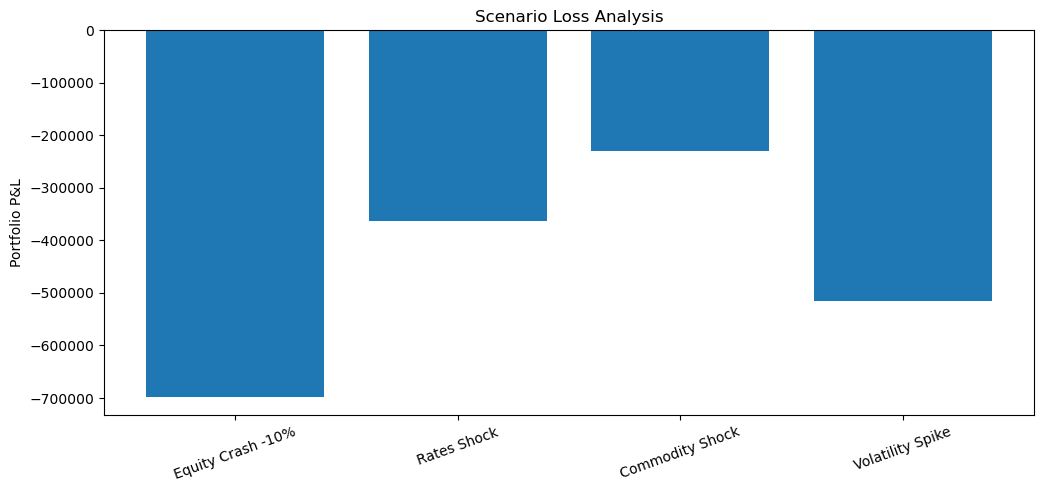

In [78]:
plt.figure(figsize=(12, 5))
plt.bar(scenario_df["Scenario"], scenario_df["Portfolio P&L"])
plt.xticks(rotation=20)
plt.title("Scenario Loss Analysis")
plt.ylabel("Portfolio P&L")
plt.show()

# Historical Stress Test

In [79]:
stress_windows = {
    "GFC": ("2008-09-01", "2009-03-31"),
    "COVID Shock": ("2020-02-20", "2020-04-30"),
    "2022 Inflation Shock": ("2022-01-01", "2022-10-31"),
}

def historical_stress_test(portfolio_pnl: pd.Series, windows: Dict[str, Tuple[str, str]]) -> pd.DataFrame:
    rows = []
    for name, (start, end) in windows.items():
        sample = portfolio_pnl.loc[start:end].dropna()
        if len(sample) == 0:
            continue

        rows.append({
            "Stress Window": name,
            "Start": start,
            "End": end,
            "Worst Day": float(sample.min()),
            "VaR 95%": var_from_pnl(sample, 0.95),
            "VaR 99%": var_from_pnl(sample, 0.99),
            "ES 97.5%": es_from_pnl(sample, 0.975),
        })
    return pd.DataFrame(rows)

stress_df = historical_stress_test(engine.portfolio["portfolio_pnl"], stress_windows)
print(stress_df)

          Stress Window       Start         End      Worst Day        VaR 95%  \
0                   GFC  2008-09-01  2009-03-31 -785093.610877  422897.408754   
1           COVID Shock  2020-02-20  2020-04-30 -868202.489047  604786.060089   
2  2022 Inflation Shock  2022-01-01  2022-10-31 -371105.586429  204336.191623   

         VaR 99%       ES 97.5%  
0  620971.758327 -636506.931787  
1  823156.958449 -822237.661906  
2  322173.767634 -307416.880885  


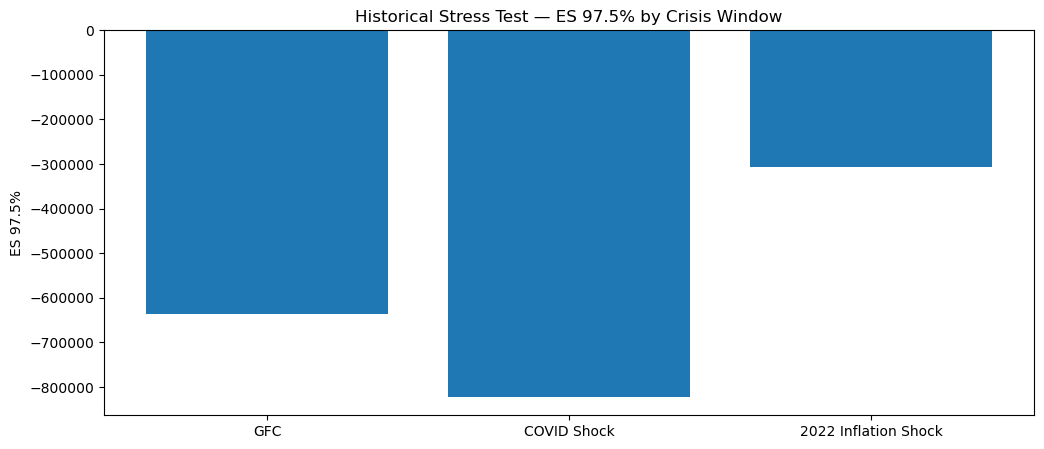

In [80]:
plt.figure(figsize=(12, 5))
plt.bar(stress_df["Stress Window"], stress_df["ES 97.5%"])
plt.title("Historical Stress Test — ES 97.5% by Crisis Window")
plt.ylabel("ES 97.5%")
plt.show()